<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/Notebooks/08_Neural_Network_Temporal_Early_Warning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Temporal Early-Warning Analysis

This notebook develops and evaluates feedforward neural networks for the SEAID Framework at four early-warning checkpoints: **Day 7, Day 14, Day 21, and Day 30**.

Neural networks can learn nonlinear relationships among student engagement, assessment performance, registration behavior, demographic characteristics, and course context. The temporal analysis asks not only whether student success can be predicted, but also **how early useful predictive performance emerges**.

The project blueprint discusses sequence-based deep learning architectures such as bidirectional LSTMs. The current SEAID temporal datasets contain one engineered record per student at each checkpoint rather than ordered sequences of activity. Therefore, a multilayer perceptron is the appropriate neural-network architecture for the present study.

## Notebook Objectives

1. Preserve the detailed Day-30 neural-network analysis.
2. Load the Day 7, Day 14, Day 21, and Day 30 temporal datasets.
3. Apply consistent leakage controls and preprocessing at every checkpoint.
4. Train a fresh regularized neural network for each temporal period.
5. Evaluate Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC.
6. Measure recall for unsuccessful students, the primary early-warning group.
7. Compare predictive performance across time.
8. Save checkpoint-specific models, preprocessors, histories, predictions, and metrics.
9. Produce temporal results for Notebook 09 model comparison.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.20.0
Libraries imported successfully.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = PROJECT_DIR / "figures"

DATA_PATH = DATA_DIR / "final_modeling_dataset_day30.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project directory: /content/drive/MyDrive/SEAID_Framework
Dataset path: /content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset_day30.csv
Dataset exists: True


## Load the Day 30 Modeling Dataset

The neural network uses the same Day 30 dataset and prediction target as the Logistic Regression, Decision Tree, Random Forest, and XGBoost early-warning models.

In [4]:
modeling_data = pd.read_csv(DATA_PATH)

In [5]:
modeling_data.shape

(32593, 77)

In [6]:
modeling_data.head()

,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,average_clicks_per_record,median_clicks_per_record,maximum_clicks_in_record,vle_records,active_days,unique_vle_activities,first_activity_day,last_activity_day,clicks_per_active_day,activity_span_days,clicks_per_vle_activity,log_total_clicks,assessments_completed,average_score,median_score,minimum_score,maximum_score,score_std,average_weight,total_weight_completed,first_submission_day,last_submission_day,banked_assessments,assessment_span_days,score_range,weighted_average_score,score_improvement,assessment_intensity,log_assessments_completed,date_registration,registered_before_start,registered_after_start,days_registered_before_start,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,424.0,6.424242,2.0,76.0,66.0,10.0,26.0,-5.0,30.0,42.400000,35.0,16.307692,6.052089,1.0,78.0,78.0,78.0,78.0,0.0,10.0,10.0,18.0,18.0,0.0,0.0,0.0,78.0,0.0,1.0,0.693147,-159.0,1,0,159.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,618.0,3.862500,2.5,19.0,160.0,19.0,34.0,-10.0,28.0,32.526316,38.0,18.176471,6.428105,1.0,70.0,70.0,70.0,70.0,0.0,10.0,10.0,22.0,22.0,0.0,0.0,0.0,70.0,0.0,1.0,0.693147,-53.0,1,0,53.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,3.697368,2.0,23.0,76.0,12.0,22.0,-10.0,12.0,23.416667,22.0,12.772727,5.641907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-92.0,1,0,92.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,540.0,3.552632,2.0,22.0,152.0,24.0,32.0,-10.0,30.0,22.500000,40.0,16.875000,6.293419,1.0,72.0,72.0,72.0,72.0,0.0,10.0,10.0,17.0,17.0,0.0,0.0,0.0,72.0,0.0,1.0,0.693147,-52.0,1,0,52.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,567.0,3.754967,2.0,22.0,151.0,24.0,34.0,-10.0,26.0,23.625000,36.0,16.676471,6.342121,1.0,69.0,69.0,69.0,69.0,0.0,10.0,10.0,26.0,26.0,0.0,0.0,0.0,69.0,0.0,1.0,0.693147,-176.0,1,0,176.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


In [7]:
TARGET = "target_success"

In [8]:
modeling_data[TARGET].value_counts()

,count
target_success,
0,17208
1,15385


In [9]:
modeling_data[TARGET].value_counts(normalize=True)

,proportion
target_success,
0,0.527966
1,0.472034


## Prepare Predictor Variables

The target variable, final course outcome, and student identifier are excluded from the predictors.

- `target_success` is the variable being predicted.
- `final_result` directly reveals the student's final outcome.
- `id_student` is an identifier and should not be treated as a generalizable predictor.

In [10]:
columns_to_drop = [
    TARGET,
    "final_result",
    "id_student"
]

In [11]:
X = modeling_data.drop(columns=columns_to_drop)
y = modeling_data[TARGET]

In [12]:
print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (32593, 74)
Target shape: (32593,)


In [13]:
print(X.dtypes.value_counts())

int64      40
float64    32
object      2
Name: count, dtype: int64


## Create Training, Validation, and Testing Datasets

The original dataset is divided into an 80% training portion and a 20% held-out test set. A validation set is then created from the training portion for neural-network monitoring and early stopping.

The final approximate proportions are:

- 64% training
- 16% validation
- 20% testing

Stratification preserves the success and non-success distribution in each split.

In [14]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [15]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

In [16]:
print("Training predictors:", X_train.shape)
print("Validation predictors:", X_validation.shape)
print("Testing predictors:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_validation.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training predictors: (20859, 74)
Validation predictors: (5215, 74)
Testing predictors: (6519, 74)

Training target distribution:
target_success
0    0.527974
1    0.472026
Name: proportion, dtype: float64

Validation target distribution:
target_success
0    0.5279
1    0.4721
Name: proportion, dtype: float64

Testing target distribution:
target_success
0    0.527995
1    0.472005
Name: proportion, dtype: float64


## Build the Preprocessing Pipeline

Neural networks are sensitive to differences in feature scale. Numeric variables are therefore median-imputed and standardized.

Categorical variables are imputed using the most frequent value and converted to one-hot indicator variables. The preprocessing pipeline is fitted only on the training data to prevent data leakage.

In [17]:
numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical feature names:", categorical_features)

Numeric features: 72
Categorical features: 2
Categorical feature names: ['code_module', 'code_presentation']


In [18]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [19]:
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

In [20]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            one_hot_encoder
        )
    ]
)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

In [23]:
X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_validation_processed = np.asarray(
    X_validation_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

In [24]:
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_validation_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (20859, 83)
Processed validation shape: (5215, 83)
Processed testing shape: (6519, 83)


In [25]:
feature_names = preprocessor.get_feature_names_out()

print("Number of neural-network input features:", len(feature_names))
print(feature_names[:20])

Number of neural-network input features: 83
['numeric__gender' 'numeric__num_of_prev_attempts'
 'numeric__studied_credits' 'numeric__disability' 'numeric__total_clicks'
 'numeric__average_clicks_per_record' 'numeric__median_clicks_per_record'
 'numeric__maximum_clicks_in_record' 'numeric__vle_records'
 'numeric__active_days' 'numeric__unique_vle_activities'
 'numeric__first_activity_day' 'numeric__last_activity_day'
 'numeric__clicks_per_active_day' 'numeric__activity_span_days'
 'numeric__clicks_per_vle_activity' 'numeric__log_total_clicks'
 'numeric__assessments_completed' 'numeric__average_score'
 'numeric__median_score']


In [26]:
print("Missing values in training matrix:", np.isnan(X_train_processed).sum())
print("Missing values in validation matrix:", np.isnan(X_validation_processed).sum())
print("Missing values in testing matrix:", np.isnan(X_test_processed).sum())

Missing values in training matrix: 0
Missing values in validation matrix: 0
Missing values in testing matrix: 0


## Calculate Class Weights

Class weights allow the model to account for differences in the frequency of successful and unsuccessful student outcomes without changing the validation or test distributions.

In [27]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_label): float(weight)
    for class_label, weight in zip(
        classes,
        class_weights_array
    )
}

class_weights

{0: 0.9470171615363661, 1: 1.0592626447288238}

## Build the Neural Network

The network contains three hidden layers. ReLU activation functions allow the model to learn nonlinear relationships. Batch normalization stabilizes training, while dropout and L2 regularization reduce overfitting.

The final sigmoid unit produces a probability between 0 and 1 for student success.

In [28]:
tf.keras.backend.clear_session()

input_dimension = X_train_processed.shape[1]

In [29]:
neural_network = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(input_dimension,),
            name="student_features"
        ),
        tf.keras.layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(0.0001),
            name="hidden_layer_1"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(0.0001),
            name="hidden_layer_2"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(
            32,
            activation="relu",
            name="hidden_layer_3"
        ),
        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="success_probability"
        )
    ],
    name="SEAID_Day30_Neural_Network"
)

In [ ]:
neural_network.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.AUC(
            curve="PR",
            name="pr_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

In [30]:
neural_network.summary()

Model: "SEAID_Day30_Neural_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ success_probability (Dense)     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,889 (85.50 KB)

 Trainable params: 21,505 (84.00 KB)

 Non-trainable params: 384 (1.50 KB)

## Train the Neural Network

Early stopping monitors validation ROC-AUC and restores the model weights from the strongest epoch. Learning-rate reduction allows the optimizer to make smaller adjustments when validation loss stops improving.

In [34]:
BEST_MODEL_PATH = (
    MODEL_DIR /
    "neural_network_day30_best.keras"
)

In [35]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.50,
        patience=5,
        min_lr=0.000001,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

In [37]:
neural_network.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.AUC(
            curve="PR",
            name="pr_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

In [38]:
history = neural_network.fit(
    X_train_processed,
    y_train,
    validation_data=(
        X_validation_processed,
        y_validation
    ),
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6285 - loss: 0.7102 - pr_auc: 0.6257 - precision: 0.5805 - recall: 0.8313 - roc_auc: 0.6876
Epoch 1: val_roc_auc improved from None to 0.79456, saving model to /content/drive/MyDrive/SEAID_Framework/models/neural_network_day30_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SEAID_Framework/models/neural_network_day30_best.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 233ms/step - accuracy: 0.6723 - loss: 0.6294 - pr_auc: 0.6616 - precision: 0.6191 - recall: 0.7946 - roc_auc: 0.7367 - val_accuracy: 0.7145 - val_loss: 0.5641 - val_pr_auc: 0.7433 - val_precision: 0.6907 - val_recall: 0.7157 - val_roc_auc: 0.7946 - learning_rate: 0.0010
Epoch 2/100
63/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7250 - loss: 0.5496 - pr_auc: 0.7414 - precision: 0.6803 - recall: 0.8015 - roc_auc: 0.7962
Epoch 2: val_roc_auc improved from 0.79456 to 0.81393, saving model to /content/drive/MyDrive/SEAID_Framework/models/neural

## Examine Training History

Learning curves help determine whether the model continued to improve, stopped learning, or began to overfit.

In [39]:
history_df = pd.DataFrame(
    history.history
)

history_df.index = (
    history_df.index + 1
)

history_df.index.name = "epoch"

In [40]:
history_df.tail()

,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
epoch,,,,,,,,,,,,,
42,0.791169,0.438863,0.843442,0.740621,0.858115,0.878341,0.751486,0.508661,0.785034,0.700481,0.827376,0.835316,0.000031
43,0.787909,0.439930,0.845136,0.737224,0.855677,0.877981,0.751103,0.508647,0.784889,0.700275,0.826564,0.835233,0.000031
44,0.792607,0.439951,0.842929,0.743172,0.856693,0.877743,0.750719,0.508908,0.784887,0.699794,0.826564,0.835132,0.000031
45,0.790882,0.439693,0.842713,0.742098,0.853646,0.877562,0.751294,0.508905,0.784698,0.700378,0.826970,0.835110,0.000016
46,0.793375,0.438105,0.844195,0.742339,0.861162,0.878842,0.750719,0.509025,0.785410,0.699931,0.826158,0.835235,0.000016


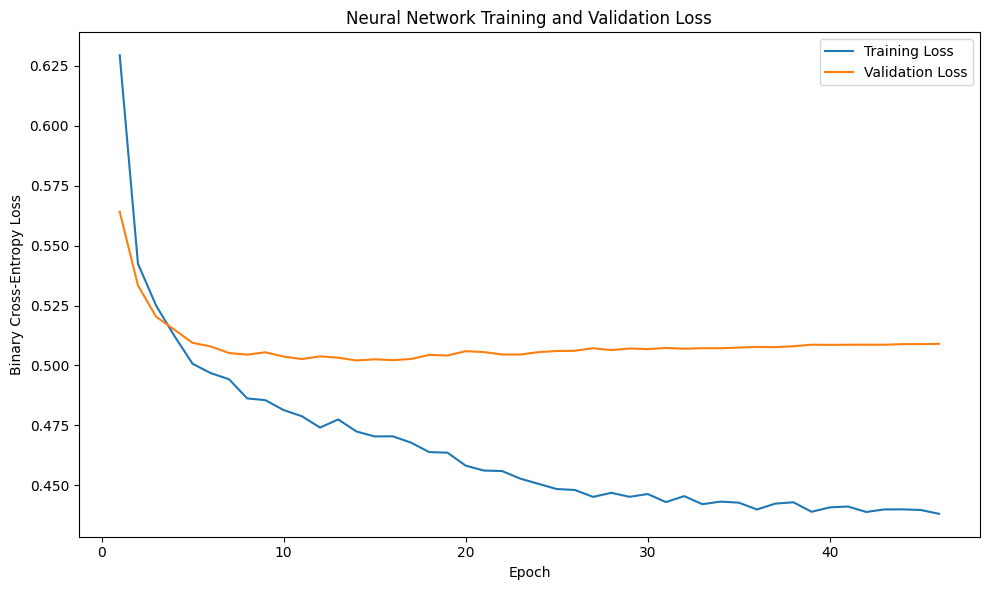

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index,
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Neural Network Training and Validation Loss")
plt.legend()
plt.tight_layout()

LOSS_CURVE_PATH = (
    FIGURE_DIR /
    "neural_network_day30_loss_curve.png"
)

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

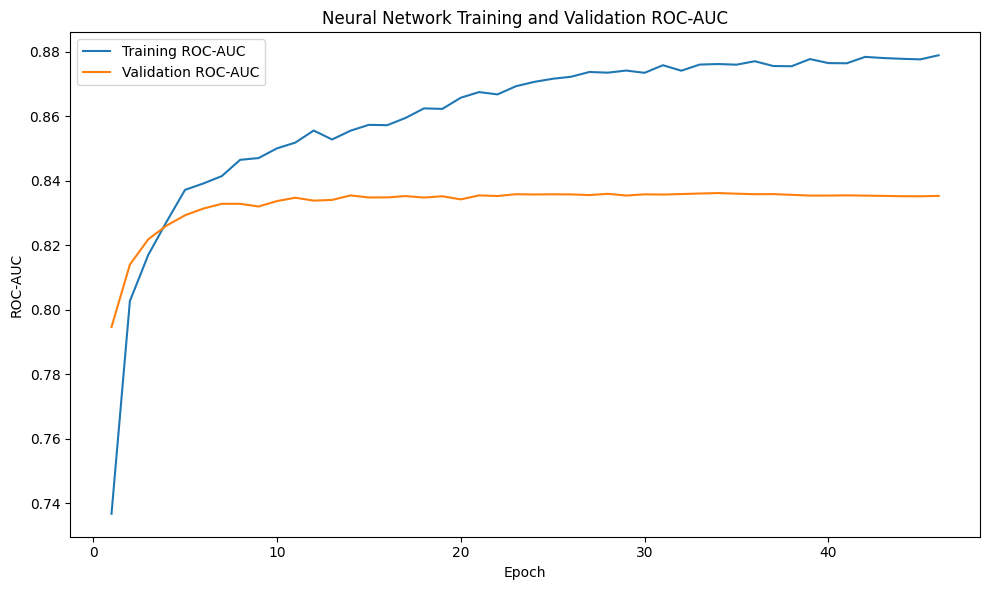

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index,
    history_df["roc_auc"],
    label="Training ROC-AUC"
)

plt.plot(
    history_df.index,
    history_df["val_roc_auc"],
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Neural Network Training and Validation ROC-AUC")
plt.legend()
plt.tight_layout()

AUC_CURVE_PATH = (
    FIGURE_DIR /
    "neural_network_day30_auc_curve.png"
)

plt.savefig(
    AUC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Evaluate Model Performance

The trained model is evaluated on the held-out test set using the same major classification measures reported for the existing SEAID models.

Because the model predicts student success, recall for class 0 is also important. Class 0 represents students who ultimately fail or withdraw and may require early outreach.

In [43]:
test_probabilities = neural_network.predict(
    X_test_processed
).ravel()

204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step


In [44]:
test_predictions = (
    test_probabilities >= 0.50
).astype(int)

In [45]:
accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

In [46]:
neural_network_metrics = pd.DataFrame(
    {
        "Model": [
            "Neural Network"
        ],
        "Accuracy": [
            accuracy
        ],
        "Precision": [
            precision
        ],
        "Recall": [
            recall
        ],
        "F1": [
            f1
        ],
        "ROC_AUC": [
            roc_auc
        ],
        "PR_AUC": [
            pr_auc
        ]
    }
)

neural_network_metrics

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Neural Network,0.768523,0.719362,0.835554,0.773117,0.849207,0.806233


In [47]:
print(
    classification_report(
        y_test,
        test_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.8282    0.7086    0.7637      3442
           1     0.7194    0.8356    0.7731      3077

    accuracy                         0.7685      6519
   macro avg     0.7738    0.7721    0.7684      6519
weighted avg     0.7768    0.7685    0.7682      6519



## Confusion Matrix

In [48]:
confusion = confusion_matrix(
    y_test,
    test_predictions
)

confusion

array([[2439, 1003],
       [ 506, 2571]])

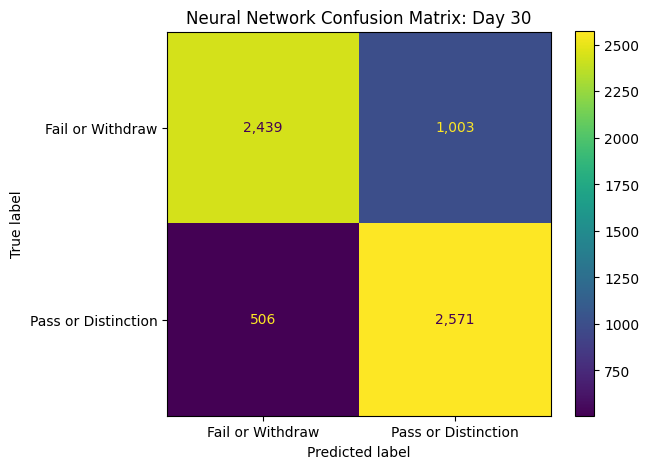

In [49]:
display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Fail or Withdraw",
        "Pass or Distinction"
    ]
)

display.plot(
    values_format=",d"
)

plt.title(
    "Neural Network Confusion Matrix: Day 30"
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    FIGURE_DIR /
    "neural_network_day30_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ROC Curve

In [50]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    test_probabilities
)

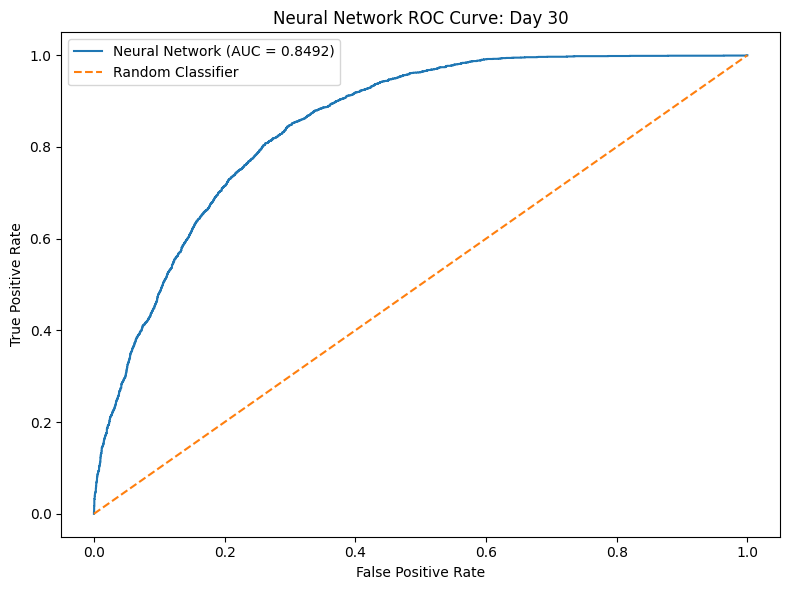

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Neural Network (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Neural Network ROC Curve: Day 30")
plt.legend()
plt.tight_layout()

ROC_CURVE_PATH = (
    FIGURE_DIR /
    "neural_network_day30_roc_curve.png"
)

plt.savefig(
    ROC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Precision-Recall Curve

In [52]:
precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

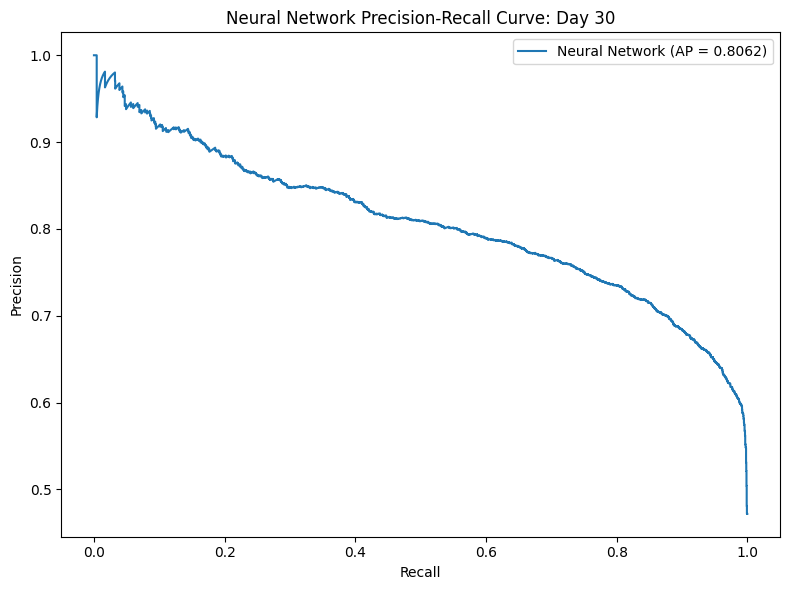

In [53]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Neural Network (AP = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Neural Network Precision-Recall Curve: Day 30")
plt.legend()
plt.tight_layout()

PR_CURVE_PATH = (
    FIGURE_DIR /
    "neural_network_day30_precision_recall_curve.png"
)

plt.savefig(
    PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Predicted Probability Distribution

The probability distribution shows how confidently the neural network separates successful and unsuccessful outcomes.

In [54]:
probability_results = pd.DataFrame(
    {
        "actual_outcome": y_test.to_numpy(),
        "predicted_probability": test_probabilities,
        "predicted_class": test_predictions
    }
)

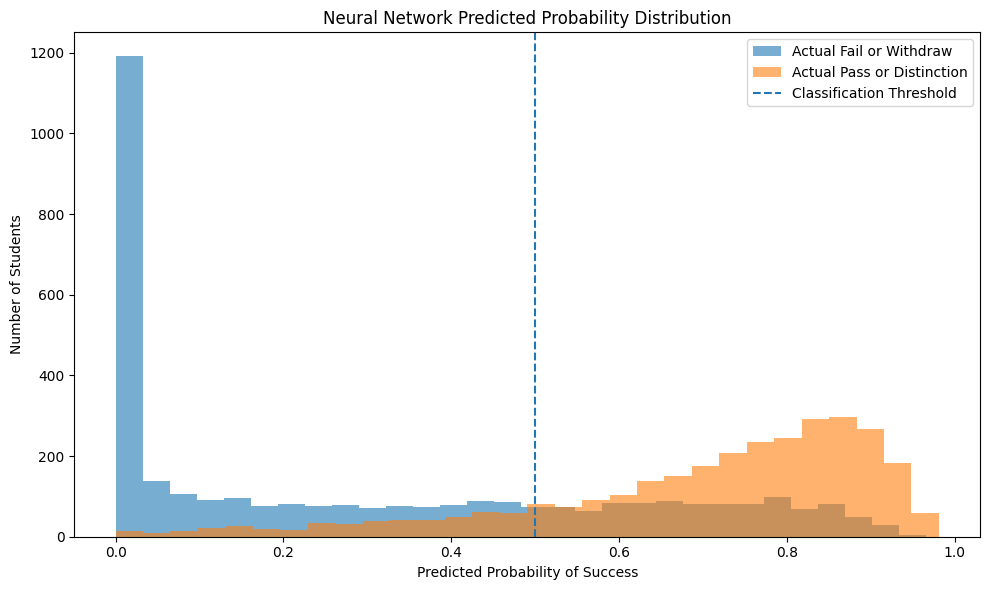

In [55]:
plt.figure(figsize=(10, 6))

plt.hist(
    probability_results.loc[
        probability_results["actual_outcome"] == 0,
        "predicted_probability"
    ],
    bins=30,
    alpha=0.60,
    label="Actual Fail or Withdraw"
)

plt.hist(
    probability_results.loc[
        probability_results["actual_outcome"] == 1,
        "predicted_probability"
    ],
    bins=30,
    alpha=0.60,
    label="Actual Pass or Distinction"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Classification Threshold"
)

plt.xlabel("Predicted Probability of Success")
plt.ylabel("Number of Students")
plt.title("Neural Network Predicted Probability Distribution")
plt.legend()
plt.tight_layout()

PROBABILITY_DISTRIBUTION_PATH = (
    FIGURE_DIR /
    "neural_network_day30_probability_distribution.png"
)

plt.savefig(
    PROBABILITY_DISTRIBUTION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Evaluate Performance Across Classification Thresholds

A 0.50 threshold is useful for model comparison, but an institutional early-warning system may choose a different threshold depending on advising capacity and the relative cost of missed students versus unnecessary alerts.

In [56]:
threshold_results = []

for threshold in np.arange(
    0.10,
    0.91,
    0.05
):
    threshold_predictions = (
        test_probabilities >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "Threshold": threshold,
            "Accuracy": accuracy_score(
                y_test,
                threshold_predictions
            ),
            "Precision": precision_score(
                y_test,
                threshold_predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                threshold_predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_test,
                threshold_predictions,
                zero_division=0
            )
        }
    )

threshold_results_df = pd.DataFrame(
    threshold_results
)

In [ ]:
threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.688296,0.603980,0.986350,0.749198
1,0.15,0.703942,0.618272,0.974326,0.756498
2,0.20,0.717595,0.631489,0.964576,0.763276
3,0.25,0.730940,0.645673,0.952876,0.769756
4,0.30,0.741832,0.659205,0.937927,0.774245
5,0.35,0.750422,0.672619,0.918102,0.776419
6,0.40,0.757018,0.685558,0.896328,0.776901
7,0.45,0.764381,0.702497,0.868703,0.776809
8,0.50,0.768523,0.719362,0.835554,0.773117
9,0.55,0.769750,0.734943,0.801105,0.766599


In [57]:
best_f1_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

best_f1_row

,6
Threshold,0.400000
Accuracy,0.757018
Precision,0.685558
Recall,0.896328
F1,0.776901


## Save the Neural-Network Artifacts

The saved preprocessing pipeline and feature names are required to transform future student records in exactly the same way as the training data.

The `.keras` file stores the TensorFlow model. CSV and JSON outputs allow Notebook 09 to include the neural network in the SEAID model comparison.

In [58]:
FINAL_MODEL_PATH = (
    MODEL_DIR /
    "neural_network_day30.keras"
)

PREPROCESSOR_PATH = (
    MODEL_DIR /
    "neural_network_day30_preprocessor.joblib"
)

FEATURE_NAMES_PATH = (
    MODEL_DIR /
    "neural_network_day30_feature_names.joblib"
)

METRICS_PATH = (
    RESULTS_DIR /
    "neural_network_day30_metrics.csv"
)

PREDICTIONS_PATH = (
    OUTPUT_DIR /
    "neural_network_day30_predictions.csv"
)

HISTORY_PATH = (
    RESULTS_DIR /
    "neural_network_day30_training_history.csv"
)

THRESHOLD_PATH = (
    RESULTS_DIR /
    "neural_network_day30_threshold_analysis.csv"
)

CONFIGURATION_PATH = (
    RESULTS_DIR /
    "neural_network_day30_configuration.json"
)

In [59]:
neural_network.save(
    FINAL_MODEL_PATH
)

joblib.dump(
    preprocessor,
    PREPROCESSOR_PATH
)

joblib.dump(
    feature_names,
    FEATURE_NAMES_PATH
)

neural_network_metrics.to_csv(
    METRICS_PATH,
    index=False
)

probability_results.to_csv(
    PREDICTIONS_PATH,
    index=False
)

history_df.to_csv(
    HISTORY_PATH
)

threshold_results_df.to_csv(
    THRESHOLD_PATH,
    index=False
)

In [60]:
model_configuration = {
    "model_name": "SEAID Day 30 Neural Network",
    "random_state": RANDOM_STATE,
    "target": TARGET,
    "training_rows": int(len(X_train)),
    "validation_rows": int(len(X_validation)),
    "testing_rows": int(len(X_test)),
    "input_features": int(input_dimension),
    "batch_size": 256,
    "maximum_epochs": 100,
    "classification_threshold": 0.50,
    "class_weights": class_weights,
    "test_roc_auc": float(roc_auc),
    "test_pr_auc": float(pr_auc)
}

with open(
    CONFIGURATION_PATH,
    "w"
) as configuration_file:
    json.dump(
        model_configuration,
        configuration_file,
        indent=4
    )

In [61]:
print("Model saved:", FINAL_MODEL_PATH.exists())
print("Preprocessor saved:", PREPROCESSOR_PATH.exists())
print("Feature names saved:", FEATURE_NAMES_PATH.exists())
print("Metrics saved:", METRICS_PATH.exists())
print("Predictions saved:", PREDICTIONS_PATH.exists())
print("Training history saved:", HISTORY_PATH.exists())
print("Threshold analysis saved:", THRESHOLD_PATH.exists())
print("Configuration saved:", CONFIGURATION_PATH.exists())

Model saved: True
Preprocessor saved: True
Feature names saved: True
Metrics saved: True
Predictions saved: True
Training history saved: True
Threshold analysis saved: True
Configuration saved: True


## Interpretation

The neural network should be interpreted alongside the traditional SEAID models rather than evaluated only by whether it produces the highest ROC-AUC.

Important considerations include:

- whether the neural network improves ROC-AUC, recall, or F1 score;
- whether the improvement is large enough to justify greater complexity;
- whether performance remains stable across the validation and test sets;
- whether the model produces probabilities that can support advisor prioritization;
- whether a simpler model provides comparable performance with greater transparency.

The strongest predictive model is not automatically the strongest institutional decision-support model. SEAID emphasizes predictive quality, explainability, fairness, operational usefulness, and human oversight.

## Connection to the Predictive Student Success Blueprint

The project blueprint frames student departure as a dynamic and multifaceted process. The current neural network incorporates that principle through engineered Day 30 indicators describing student engagement, assessment behavior, registration timing, prior educational experience, and course context.

A future extension could restructure raw OULAD activity into ordered weekly or daily sequences and evaluate recurrent architectures such as LSTM or bidirectional LSTM models. That extension would represent a separate sequence-modeling study because it requires a different dataset structure from the current one-record-per-student SEAID modeling table.

## Notebook Summary

This notebook added a deep-learning model to the SEAID early-warning framework.

The completed workflow:

1. Loaded the Day 30 modeling dataset.
2. removed target leakage and identifier variables.
3. Created training, validation, and testing datasets.
4. Imputed and standardized numeric variables.
5. Encoded categorical variables.
6. Calculated class weights.
7. Built a regularized feedforward neural network.
8. Trained the model with early stopping and learning-rate reduction.
9. Evaluated classification and probability-ranking performance.
10. Examined threshold tradeoffs.
11. Saved the model, preprocessing pipeline, feature names, predictions, metrics, training history, and visualizations.

The resulting metrics file can now be incorporated into Notebook 09 for direct comparison with Logistic Regression, Decision Tree, Random Forest, and XGBoost.

# Temporal Neural-Network Comparison

This section mirrors the temporal structure used in Notebook 04. Separate neural networks are trained for the Day 7, Day 14, Day 21, and Day 30 datasets.

Each checkpoint uses:

- the same target definition;
- the same leakage and identifier exclusions;
- an 80/20 stratified train-test split;
- a validation subset drawn from the training data;
- checkpoint-specific preprocessing fitted only on the training set;
- the same neural-network architecture and training rules;
- the same 0.50 classification threshold for fair comparison.

A fresh model is initialized at every checkpoint so information learned from a later period cannot influence an earlier model.

In [62]:
TEMPORAL_DATASETS = {
    7: DATA_DIR / "early_warning_day7_dataset.csv",
    14: DATA_DIR / "early_warning_day14_dataset.csv",
    21: DATA_DIR / "early_warning_day21_dataset.csv",
    30: DATA_DIR / "early_warning_day30_dataset.csv"
}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():
    print(
        f"Day {checkpoint_day}: "
        f"{dataset_path.name} | "
        f"Exists: {dataset_path.exists()}"
    )

Day 7: early_warning_day7_dataset.csv | Exists: True
Day 14: early_warning_day14_dataset.csv | Exists: True
Day 21: early_warning_day21_dataset.csv | Exists: True
Day 30: early_warning_day30_dataset.csv | Exists: True


## Temporal Modeling Functions

The helper functions below ensure that every checkpoint is processed and evaluated consistently.

In [63]:
def build_temporal_preprocessor(X_train_checkpoint):
    """Create a checkpoint-specific preprocessing pipeline."""

    numeric_features_checkpoint = (
        X_train_checkpoint
        .select_dtypes(include=["number", "bool"])
        .columns
        .tolist()
    )

    categorical_features_checkpoint = (
        X_train_checkpoint
        .select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    numeric_transformer_checkpoint = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    try:
        checkpoint_encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        checkpoint_encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

    categorical_transformer_checkpoint = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            ("encoder", checkpoint_encoder)
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_transformer_checkpoint,
                numeric_features_checkpoint
            ),
            (
                "categorical",
                categorical_transformer_checkpoint,
                categorical_features_checkpoint
            )
        ]
    )

In [64]:
def build_temporal_neural_network(input_dimension):
    """Build a fresh regularized multilayer perceptron."""

    tf.keras.backend.clear_session()

    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(
                shape=(input_dimension,),
                name="student_features"
            ),
            tf.keras.layers.Dense(
                128,
                activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(0.0001)
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.30),
            tf.keras.layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(0.0001)
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.20),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid")
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

## Train One Neural Network at Each Checkpoint

The saved results distinguish successful-student recall from unsuccessful-student recall. Because `target_success = 0` represents students who fail or withdraw, **Recall - Unsuccessful** is especially important for early intervention.

In [65]:
temporal_results = []
temporal_models = {}
temporal_preprocessors = {}
temporal_histories = {}
temporal_predictions = {}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():

    print("=" * 70)
    print(f"Training Day {checkpoint_day} neural network")
    print("=" * 70)

    checkpoint_df = pd.read_csv(dataset_path)

    checkpoint_columns_to_exclude = [
        TARGET,
        "checkpoint_day",
        "final_result",
        "id_student",
        "code_module",
        "code_presentation",
        "withdrew",
        "early_withdrawal",
        "date_unregistration",
        "days_until_withdrawal"
    ]

    checkpoint_columns_to_exclude = [
        column
        for column in checkpoint_columns_to_exclude
        if column in checkpoint_df.columns
    ]

    X_checkpoint = checkpoint_df.drop(
        columns=checkpoint_columns_to_exclude
    )

    y_checkpoint = checkpoint_df[TARGET].astype(int)

    X_checkpoint = X_checkpoint.replace(
        [np.inf, -np.inf],
        np.nan
    )

    (
        X_train_full_checkpoint,
        X_test_checkpoint,
        y_train_full_checkpoint,
        y_test_checkpoint
    ) = train_test_split(
        X_checkpoint,
        y_checkpoint,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_checkpoint
    )

    (
        X_train_checkpoint,
        X_validation_checkpoint,
        y_train_checkpoint,
        y_validation_checkpoint
    ) = train_test_split(
        X_train_full_checkpoint,
        y_train_full_checkpoint,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train_full_checkpoint
    )

    checkpoint_preprocessor = build_temporal_preprocessor(
        X_train_checkpoint
    )

    X_train_processed_checkpoint = np.asarray(
        checkpoint_preprocessor.fit_transform(X_train_checkpoint),
        dtype=np.float32
    )

    X_validation_processed_checkpoint = np.asarray(
        checkpoint_preprocessor.transform(X_validation_checkpoint),
        dtype=np.float32
    )

    X_test_processed_checkpoint = np.asarray(
        checkpoint_preprocessor.transform(X_test_checkpoint),
        dtype=np.float32
    )

    checkpoint_classes = np.unique(y_train_checkpoint)

    checkpoint_class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=checkpoint_classes,
        y=y_train_checkpoint
    )

    checkpoint_class_weights = {
        int(class_label): float(weight)
        for class_label, weight in zip(
            checkpoint_classes,
            checkpoint_class_weights_array
        )
    }

    checkpoint_model = build_temporal_neural_network(
        X_train_processed_checkpoint.shape[1]
    )

    checkpoint_best_model_path = (
        MODEL_DIR /
        f"neural_network_day{checkpoint_day}_best.keras"
    )

    checkpoint_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_roc_auc",
            mode="max",
            patience=12,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.50,
            patience=5,
            min_lr=0.000001,
            verbose=0
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_best_model_path,
            monitor="val_roc_auc",
            mode="max",
            save_best_only=True,
            verbose=0
        )
    ]

    checkpoint_history = checkpoint_model.fit(
        X_train_processed_checkpoint,
        y_train_checkpoint,
        validation_data=(
            X_validation_processed_checkpoint,
            y_validation_checkpoint
        ),
        epochs=100,
        batch_size=256,
        class_weight=checkpoint_class_weights,
        callbacks=checkpoint_callbacks,
        verbose=0
    )

    checkpoint_probabilities = checkpoint_model.predict(
        X_test_processed_checkpoint,
        verbose=0
    ).ravel()

    checkpoint_predictions = (
        checkpoint_probabilities >= 0.50
    ).astype(int)

    checkpoint_confusion = confusion_matrix(
        y_test_checkpoint,
        checkpoint_predictions,
        labels=[0, 1]
    )

    true_negative = checkpoint_confusion[0, 0]
    false_positive = checkpoint_confusion[0, 1]
    false_negative = checkpoint_confusion[1, 0]
    true_positive = checkpoint_confusion[1, 1]

    unsuccessful_recall = (
        true_negative / (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else np.nan
    )

    temporal_results.append(
        {
            "Checkpoint Day": checkpoint_day,
            "Students": len(checkpoint_df),
            "Features": X_train_processed_checkpoint.shape[1],
            "Training Epochs": len(checkpoint_history.history["loss"]),
            "Accuracy": accuracy_score(
                y_test_checkpoint,
                checkpoint_predictions
            ),
            "Precision - Successful": precision_score(
                y_test_checkpoint,
                checkpoint_predictions,
                zero_division=0
            ),
            "Recall - Successful": recall_score(
                y_test_checkpoint,
                checkpoint_predictions,
                zero_division=0
            ),
            "Recall - Unsuccessful": unsuccessful_recall,
            "F1 Score": f1_score(
                y_test_checkpoint,
                checkpoint_predictions,
                zero_division=0
            ),
            "ROC-AUC": roc_auc_score(
                y_test_checkpoint,
                checkpoint_probabilities
            ),
            "PR-AUC": average_precision_score(
                y_test_checkpoint,
                checkpoint_probabilities
            ),
            "At-Risk Students Missed": false_positive,
            "Successful Students Flagged": false_negative
        }
    )

    temporal_models[checkpoint_day] = checkpoint_model
    temporal_preprocessors[checkpoint_day] = checkpoint_preprocessor
    temporal_histories[checkpoint_day] = pd.DataFrame(
        checkpoint_history.history
    )
    temporal_predictions[checkpoint_day] = pd.DataFrame(
        {
            "actual_outcome": y_test_checkpoint.to_numpy(),
            "predicted_probability": checkpoint_probabilities,
            "predicted_class": checkpoint_predictions
        }
    )

    print(
        f"Day {checkpoint_day} complete | "
        f"ROC-AUC: {temporal_results[-1]['ROC-AUC']:.4f} | "
        f"Recall - Unsuccessful: "
        f"{temporal_results[-1]['Recall - Unsuccessful']:.4f}"
    )

Training Day 7 neural network
Day 7 complete | ROC-AUC: 0.7706 | Recall - Unsuccessful: 0.6435
Training Day 14 neural network
Day 14 complete | ROC-AUC: 0.7879 | Recall - Unsuccessful: 0.6374
Training Day 21 neural network
Day 21 complete | ROC-AUC: 0.8201 | Recall - Unsuccessful: 0.6886
Training Day 30 neural network
Day 30 complete | ROC-AUC: 0.8371 | Recall - Unsuccessful: 0.6915


## Temporal Results Table

In [66]:
temporal_results_df = pd.DataFrame(temporal_results)

temporal_results_df = (
    temporal_results_df
    .sort_values("Checkpoint Day")
    .reset_index(drop=True)
)

metric_columns = [
    "Accuracy",
    "Precision - Successful",
    "Recall - Successful",
    "Recall - Unsuccessful",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

temporal_results_df[metric_columns] = (
    temporal_results_df[metric_columns]
    .round(4)
)

temporal_results_df

,Checkpoint Day,Students,Features,Training Epochs,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,PR-AUC,At-Risk Students Missed,Successful Students Flagged
0,7,32593,72,24,0.6970,0.6549,0.7569,0.6435,0.7022,0.7706,0.7246,1227,748
1,14,32593,72,23,0.7062,0.6588,0.7832,0.6374,0.7157,0.7879,0.7385,1248,667
2,21,32593,72,37,0.7397,0.6958,0.7969,0.6886,0.7429,0.8201,0.7714,1072,625
3,30,32593,72,39,0.7500,0.7026,0.8154,0.6915,0.7548,0.8371,0.7905,1062,568


## Temporal Performance Visualization

The figure shows how model performance changes as additional engagement and assessment information becomes available.

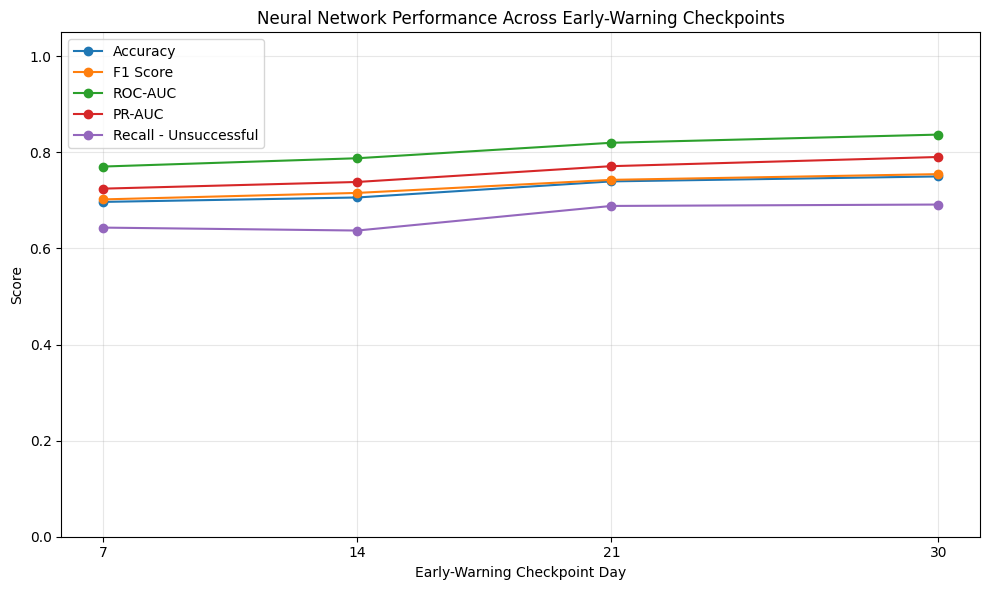

Saved:
/content/drive/MyDrive/SEAID_Framework/figures/neural_network_temporal_performance.png


In [67]:
plt.figure(figsize=(10, 6))

for metric in [
    "Accuracy",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
    "Recall - Unsuccessful"
]:
    plt.plot(
        temporal_results_df["Checkpoint Day"],
        temporal_results_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("Score")
plt.title("Neural Network Performance Across Early-Warning Checkpoints")
plt.xticks([7, 14, 21, 30])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

TEMPORAL_FIGURE_PATH = (
    FIGURE_DIR /
    "neural_network_temporal_performance.png"
)

plt.savefig(
    TEMPORAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(TEMPORAL_FIGURE_PATH)

## ROC-AUC and At-Risk Recall by Checkpoint

ROC-AUC measures overall ranking performance. Recall for unsuccessful students measures how effectively the model identifies students who eventually fail or withdraw.

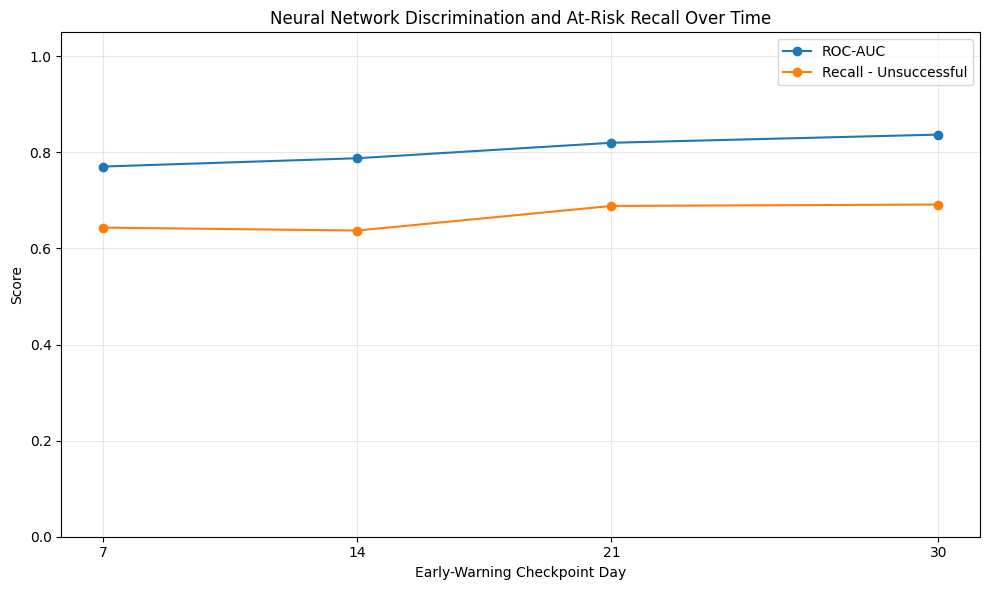

In [68]:
plt.figure(figsize=(10, 6))

plt.plot(
    temporal_results_df["Checkpoint Day"],
    temporal_results_df["ROC-AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.plot(
    temporal_results_df["Checkpoint Day"],
    temporal_results_df["Recall - Unsuccessful"],
    marker="o",
    label="Recall - Unsuccessful"
)

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("Score")
plt.title("Neural Network Discrimination and At-Risk Recall Over Time")
plt.xticks([7, 14, 21, 30])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

TEMPORAL_PRIORITY_FIGURE_PATH = (
    FIGURE_DIR /
    "neural_network_temporal_roc_auc_at_risk_recall.png"
)

plt.savefig(
    TEMPORAL_PRIORITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Save Temporal Models and Results

Each checkpoint model is saved with its own preprocessing object, training history, and test predictions. This supports reproducibility and later deployment testing.

In [69]:
TEMPORAL_RESULTS_PATH = (
    RESULTS_DIR /
    "neural_network_temporal_results.csv"
)

TEMPORAL_COMPARISON_PATH = (
    RESULTS_DIR /
    "neural_network_temporal_model_comparison.csv"
)

temporal_results_df.to_csv(
    TEMPORAL_RESULTS_PATH,
    index=False
)

temporal_comparison_df = temporal_results_df.rename(
    columns={
        "F1 Score": "F1",
        "ROC-AUC": "ROC_AUC",
        "PR-AUC": "PR_AUC"
    }
).copy()

temporal_comparison_df.insert(
    0,
    "Model",
    "Neural Network"
)

temporal_comparison_df.to_csv(
    TEMPORAL_COMPARISON_PATH,
    index=False
)

for checkpoint_day in TEMPORAL_DATASETS:

    checkpoint_model_path = (
        MODEL_DIR /
        f"neural_network_day{checkpoint_day}.keras"
    )

    checkpoint_preprocessor_path = (
        MODEL_DIR /
        f"neural_network_day{checkpoint_day}_preprocessor.joblib"
    )

    checkpoint_history_path = (
        RESULTS_DIR /
        f"neural_network_day{checkpoint_day}_training_history.csv"
    )

    checkpoint_predictions_path = (
        OUTPUT_DIR /
        f"neural_network_day{checkpoint_day}_predictions.csv"
    )

    temporal_models[checkpoint_day].save(
        checkpoint_model_path
    )

    joblib.dump(
        temporal_preprocessors[checkpoint_day],
        checkpoint_preprocessor_path
    )

    temporal_histories[checkpoint_day].to_csv(
        checkpoint_history_path,
        index_label="epoch"
    )

    temporal_predictions[checkpoint_day].to_csv(
        checkpoint_predictions_path,
        index=False
    )

print("Saved temporal results:")
print(TEMPORAL_RESULTS_PATH)

print("\nSaved Notebook 09 comparison file:")
print(TEMPORAL_COMPARISON_PATH)

print("\nSaved checkpoint-specific models and supporting artifacts.")

Saved temporal results:
/content/drive/MyDrive/SEAID_Framework/results/neural_network_temporal_results.csv

Saved Notebook 09 comparison file:
/content/drive/MyDrive/SEAID_Framework/results/neural_network_temporal_model_comparison.csv

Saved checkpoint-specific models and supporting artifacts.
